#### *Written by: Ryan Joseph C¶. Dungca, 2ECE-D*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## A. Visayas Communicaton Dataframe

In [2]:
board = pd.read_excel('board2.xlsx')
board['Average']=(board['Math'] + board['Electronics'] + board['GEAS'] + board['Communication'])/4
board # check

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [3]:
VisComm = board.loc[(board['Hometown']=='Visayas')&(board['Track']=='Communication'), ['Name', 'Gender', 'Math', 'Electronics','Average']]
VisComm # check

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [4]:
# combine results

display(VisComm)
print(len(VisComm))

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


5


## B. Visayas Female Dataframe

In [5]:
VisFemale = board.loc[(board['Hometown']=='Visayas')&(board['Gender']=='Female'), ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
VisFemale # check

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [6]:
# combine results

display(VisFemale)
display(VisFemale.loc[VisFemale['Average']>=60])

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## C. Category-Average Visualization

In [7]:
mtrack = board.pivot_table(index='Track', values='Average').reset_index()
mgender = board.pivot_table(index='Gender', values='Average').reset_index()
mregion = board.pivot_table(index='Hometown', values='Average').reset_index()
# aggfunc defaults to mean if not set

display(mtrack)
display(mgender)
display(mregion) # all for checking

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


,Gender,Average
0,Female,66.616667
1,Male,67.183333


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


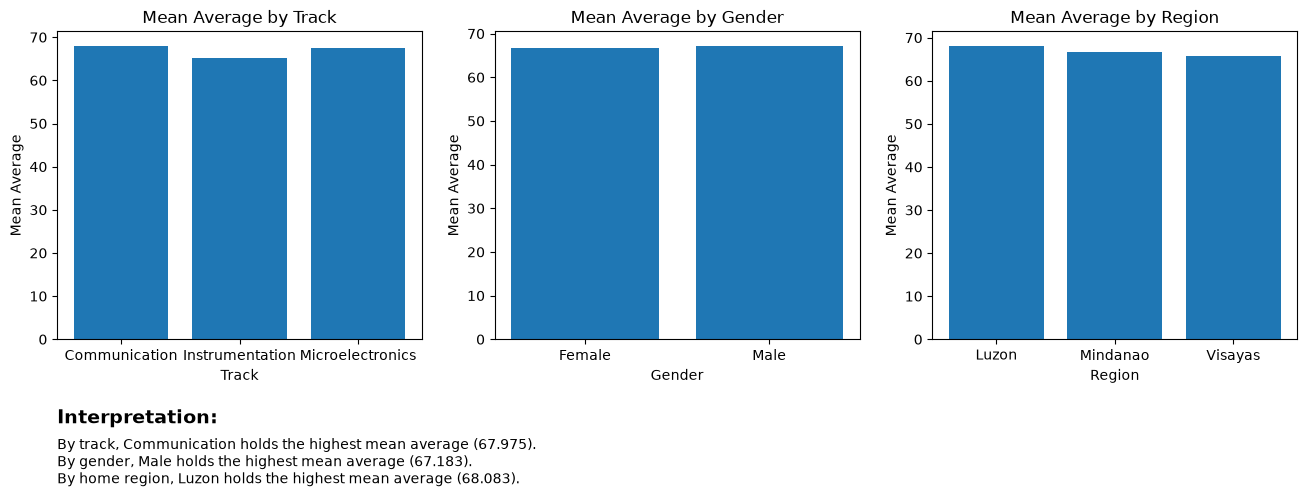

In [8]:
graph, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,4)) # works like a numpy matrix, for graphs

axes[0].bar(mtrack['Track'], mtrack['Average'])
axes[0].set(title='Mean Average by Track', xlabel='Track', ylabel='Mean Average')

axes[1].bar(mgender['Gender'], mgender['Average'])
axes[1].set(title='Mean Average by Gender', xlabel='Gender', ylabel='Mean Average')

axes[2].bar(mregion['Hometown'], mregion['Average'])
axes[2].set(title='Mean Average by Region', xlabel='Region', ylabel='Mean Average')

# text: x, y-coordinates relative to the original size of the figure; will expand figure if not enough space.
graph.text(0.125, -0.1, 'Interpretation:', weight='bold', size=14)
graph.text(0.125, -0.25, 'By track, Communication holds the highest mean average (67.975).\n'
           'By gender, Male holds the highest mean average (67.183).\n'
          'By home region, Luzon holds the highest mean average (68.083).')

# the only result
plt.show()